<a href="https://colab.research.google.com/github/nivethithanm/torchcode-solutions/blob/main/TC_25b_flash_attention_benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MASTER-04: FlashAttention Benchmarking — Time & Memory Comparison

**Time**: ~1.5 hours | **Requires**: GPU (L4 or T4)

Compare three implementations side by side at EVERY sequence length:
1. **Standard attention** — materialized N×N matrix
2. **Your manual FlashAttention** — correct algorithm, Python loops
3. **PyTorch SDPA** — `F.scaled_dot_product_attention` (C++/CUDA FlashAttention-2)

**The manual FA is never skipped.** You'll see exactly where Python loop overhead dominates, and why C++/CUDA matters.

In [12]:
import torch
import torch.nn.functional as F
import math
import time
import gc
from typing import Callable, Dict, Optional
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6GB


## 1. The Three Implementations

In [13]:
# Implementation 1: Standard attention (materialized N×N)
def standard_attention(Q, K, V, causal=True):
    """Standard attention — allocates the full N×N score matrix."""
    scale = 1.0 / math.sqrt(Q.shape[-1])
    S = torch.matmul(Q, K.transpose(-2, -1)) * scale
    if causal:
        N = S.shape[-1]
        mask = torch.triu(torch.ones(N, N, device=S.device, dtype=torch.bool), diagonal=1)
        S.masked_fill_(mask, float('-inf'))
    P = torch.softmax(S, dim=-1)
    return torch.matmul(P, V)

In [14]:
# Implementation 2: YOUR manual FlashAttention (Python loops, correct algorithm)
def manual_flash_attention(Q, K, V, block_size=64, causal=True):
    """Your FlashAttention — tiled with online softmax.
    This is the SAME algorithm as SDPA, but in Python.
    The speed difference = implementation language overhead, NOT algorithmic.
    """
    B, H, N, D = Q.shape
    O = torch.zeros_like(Q)
    scale = 1.0 / math.sqrt(D)

    for b in range(B):
        for h in range(H):
            row_max = torch.full((N,), float('-inf'), device=Q.device, dtype=Q.dtype)
            row_sum = torch.zeros(N, device=Q.device, dtype=Q.dtype)
            row_out = torch.zeros(N, D, device=Q.device, dtype=Q.dtype)

            for q_s in range(0, N, block_size):
                q_e = min(q_s + block_size, N)
                Qb = Q[b, h, q_s:q_e]

                for kv_s in range(0, N, block_size):
                    kv_e = min(kv_s + block_size, N)
                    Kb = K[b, h, kv_s:kv_e]
                    Vb = V[b, h, kv_s:kv_e]

                    Sb = (Qb @ Kb.T) * scale

                    if causal:
                        qi_idx = torch.arange(q_s, q_e, device=Sb.device).unsqueeze(1)
                        ki_idx = torch.arange(kv_s, kv_e, device=Sb.device).unsqueeze(0)
                        Sb = Sb.masked_fill(qi_idx < ki_idx, float('-inf'))

                    block_max = Sb.max(dim=-1).values
                    new_max = torch.maximum(row_max[q_s:q_e], block_max)

                    old_correction = torch.exp(row_max[q_s:q_e] - new_max)
                    block_exp = torch.exp(Sb - new_max.unsqueeze(1))

                    row_out[q_s:q_e] = row_out[q_s:q_e] * old_correction.unsqueeze(1) + block_exp @ Vb
                    row_sum[q_s:q_e] = row_sum[q_s:q_e] * old_correction + block_exp.sum(dim=-1)
                    row_max[q_s:q_e] = new_max

            O[b, h] = row_out / row_sum.unsqueeze(1)

    return O

In [15]:
# Implementation 3: PyTorch SDPA (optimized C++/CUDA)
def pytorch_sdpa(Q, K, V, causal=True):
    """PyTorch's built-in scaled_dot_product_attention.
    Uses FlashAttention-2 (CUDA), Memory-Efficient attention, or Math backend.
    """
    with torch.no_grad():
        return F.scaled_dot_product_attention(Q, K, V, is_causal=causal)

## 2. Correctness — All Three Must Match

In [16]:
torch.manual_seed(42)
B, H, N, D = 1, 2, 64, 32
Q = torch.randn(B, H, N, D, device=device)
K = torch.randn(B, H, N, D, device=device)
V = torch.randn(B, H, N, D, device=device)

with torch.no_grad():
    out_standard = standard_attention(Q, K, V)
    out_manual = manual_flash_attention(Q, K, V, block_size=16)
    out_sdpa = pytorch_sdpa(Q, K, V)

print('Correctness (max absolute difference):')
print(f'  Standard  vs Manual FA: {(out_standard - out_manual).abs().max():.2e}')
print(f'  Standard  vs SDPA:      {(out_standard - out_sdpa).abs().max():.2e}')
print(f'  Manual FA vs SDPA:      {(out_manual - out_sdpa).abs().max():.2e}')
print()
print('✅ All three produce the same result.')
print('The ALGORITHM is identical. Only the implementation language differs.')

del Q, K, V, out_standard, out_manual, out_sdpa
if device == 'cuda': torch.cuda.empty_cache()

Correctness (max absolute difference):
  Standard  vs Manual FA: 4.77e-07
  Standard  vs SDPA:      3.58e-07
  Manual FA vs SDPA:      6.26e-07

✅ All three produce the same result.
The ALGORITHM is identical. Only the implementation language differs.


## 3. Timing Benchmark — ALL Three at Every N

In [17]:
def benchmark_time(fn, Q, K, V, n_warmup=2, n_runs=5):
    """Benchmark with warmup and CUDA sync."""
    for _ in range(n_warmup):
        _ = fn(Q, K, V)
        if device == 'cuda': torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        if device == 'cuda': torch.cuda.synchronize()
        start = time.perf_counter()
        _ = fn(Q, K, V)
        if device == 'cuda': torch.cuda.synchronize()
        times.append(time.perf_counter() - start)

    avg_ms = sum(times) / len(times) * 1000
    return avg_ms

In [18]:
print(f'\n{"="*80}')
print(f'{"TIMING BENCHMARK — ALL THREE IMPLEMENTATIONS":^80}')
print(f'{"="*80}')
print(f'{"N":>6} │ {"Standard":>12} │ {"Manual FA":>12} │ {"PyTorch SDPA":>12} │ {"Manual/SDPA":>12}')
print(f'{"": >6} │ {"(ms)":>12} │ {"(ms)":>12} │ {"(ms)":>12} │ {"(ratio)":>12}')
print('─' * 80)

B, H, D = 1, 4, 64
results = []

for N in [32, 64, 128, 256, 512, 1024]:
    Q = torch.randn(B, H, N, D, device=device)
    K = torch.randn(B, H, N, D, device=device)
    V = torch.randn(B, H, N, D, device=device)

    with torch.no_grad():
        t_std = benchmark_time(standard_attention, Q, K, V)
        t_manual = benchmark_time(
            lambda q,k,v: manual_flash_attention(q, k, v, block_size=min(64, N)),
            Q, K, V, n_warmup=1, n_runs=3
        )
        t_sdpa = benchmark_time(pytorch_sdpa, Q, K, V)

    ratio = t_manual / t_sdpa
    results.append({'N': N, 'standard': t_std, 'manual_fa': t_manual, 'sdpa': t_sdpa, 'ratio': ratio})

    print(f'{N:>6} │ {t_std:>10.2f}ms │ {t_manual:>10.2f}ms │ {t_sdpa:>10.2f}ms │ {ratio:>10.0f}x')

    del Q, K, V
    if device == 'cuda': torch.cuda.empty_cache()

print('─' * 80)
print(f'\nManual FA is {results[-1]["ratio"]:.0f}x slower than SDPA at N={results[-1]["N"]}')
print('Same algorithm. The difference is Python loop dispatch vs C++/CUDA parallelism.')
print('This is WHY Triton and CUDA kernels exist.')


                  TIMING BENCHMARK — ALL THREE IMPLEMENTATIONS                  
     N │     Standard │    Manual FA │ PyTorch SDPA │  Manual/SDPA
       │         (ms) │         (ms) │         (ms) │      (ratio)
────────────────────────────────────────────────────────────────────────────────
    32 │       0.41ms │       2.03ms │       0.06ms │         36x
    64 │       0.17ms │       1.97ms │       0.06ms │         32x
   128 │       0.18ms │       6.71ms │       0.09ms │         72x
   256 │       0.23ms │      25.54ms │       0.14ms │        181x
   512 │       0.40ms │     100.92ms │       0.28ms │        365x
  1024 │       1.31ms │     407.54ms │       0.70ms │        586x
────────────────────────────────────────────────────────────────────────────────

Manual FA is 586x slower than SDPA at N=1024
Same algorithm. The difference is Python loop dispatch vs C++/CUDA parallelism.
This is WHY Triton and CUDA kernels exist.


## 4. Memory Benchmark — ALL Three at Every N

In [19]:
def benchmark_memory(fn, Q, K, V):
    """Measure peak GPU memory ABOVE baseline."""
    if device != 'cuda':
        return 0.0
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    baseline = torch.cuda.memory_allocated()

    with torch.no_grad():
        out = fn(Q, K, V)
        torch.cuda.synchronize()

    peak = torch.cuda.max_memory_allocated()
    del out
    gc.collect()
    torch.cuda.empty_cache()
    return peak - baseline

In [20]:
if device == 'cuda':
    print(f'\n{"="*90}')
    print(f'{"MEMORY BENCHMARK — ALL THREE IMPLEMENTATIONS":^90}')
    print(f'{"="*90}')
    print(f'{"N":>6} │ {"Standard":>14} │ {"Manual FA":>14} │ {"PyTorch SDPA":>14} │ {"Std/SDPA":>10}')
    print('─' * 90)

    B, H, D = 1, 4, 64
    mem_results = []

    for N in [128, 256, 512, 1024, 2048, 4096]:
        Q = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
        K = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
        V = torch.randn(B, H, N, D, device=device, dtype=torch.float16)

        mem_std = benchmark_memory(standard_attention, Q, K, V)
        mem_manual = benchmark_memory(
            lambda q,k,v: manual_flash_attention(q, k, v, block_size=min(64, N)),
            Q, K, V
        )
        mem_sdpa = benchmark_memory(pytorch_sdpa, Q, K, V)

        savings = mem_std / max(mem_sdpa, 1)
        mem_results.append({'N': N, 'standard': mem_std, 'manual_fa': mem_manual,
                            'sdpa': mem_sdpa, 'savings': savings})

        print(f'{N:>6} │ {mem_std/1e6:>11.2f} MB │ {mem_manual/1e6:>11.2f} MB │ {mem_sdpa/1e6:>11.2f} MB │ {savings:>8.1f}x')

        del Q, K, V
        torch.cuda.empty_cache()

    print('─' * 90)
    print(f'\nStandard: O(N²) — the N×N score matrix dominates')
    print(f'Manual FA: O(N) blocks — but Python overhead adds constant memory')
    print(f'SDPA: O(N) — tightest implementation, fused CUDA kernels')
    print(f'\nNotice: Manual FA memory should be LOWER than standard (no N×N matrix).')
    print(f'If it\'s not significantly lower, it\'s because PyTorch still allocates')
    print(f'intermediate tensors for each block in Python-level operations.')
else:
    print('Memory benchmark requires CUDA')
    mem_results = []


                       MEMORY BENCHMARK — ALL THREE IMPLEMENTATIONS                       
     N │       Standard │      Manual FA │   PyTorch SDPA │   Std/SDPA
──────────────────────────────────────────────────────────────────────────────────────────
   128 │        0.34 MB │        0.13 MB │        0.07 MB │      5.2x
   256 │        1.25 MB │        0.22 MB │        0.13 MB │      9.5x
   512 │        4.72 MB │        0.41 MB │        0.26 MB │     18.0x
  1024 │       18.35 MB │        0.81 MB │        0.52 MB │     35.0x
  2048 │       72.35 MB │        1.60 MB │        1.05 MB │     69.0x
  4096 │      287.31 MB │        3.18 MB │        2.10 MB │    137.0x
──────────────────────────────────────────────────────────────────────────────────────────

Standard: O(N²) — the N×N score matrix dominates
Manual FA: O(N) blocks — but Python overhead adds constant memory
SDPA: O(N) — tightest implementation, fused CUDA kernels

Notice: Manual FA memory should be LOWER than standard (no N×

## 5. OOM Stress Test — ALL Three

In [21]:
if device == 'cuda':
    print(f'\n{"="*70}')
    print(f'{"OOM STRESS TEST — Maximum Sequence Length":^70}')
    print(f'{"="*70}')
    print(f'{"N":>8} │ {"Standard":>12} │ {"Manual FA":>12} │ {"SDPA":>12}')
    print('─' * 70)

    B, H, D = 1, 8, 128

    for N in [512, 1024, 2048, 4096, 8192, 16384]:
        statuses = {}

        for name, fn in [('standard', standard_attention),
                          ('manual_fa', lambda q,k,v: manual_flash_attention(q,k,v, block_size=64)),
                          ('sdpa', pytorch_sdpa)]:
            gc.collect()
            torch.cuda.empty_cache()
            try:
                Q = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
                K = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
                V = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
                with torch.no_grad():
                    out = fn(Q, K, V)
                    torch.cuda.synchronize()
                statuses[name] = '✅'
                del out
            except (torch.cuda.OutOfMemoryError, RuntimeError):
                statuses[name] = '❌ OOM'
            finally:
                try:
                    del Q, K, V
                except:
                    pass
                gc.collect()
                torch.cuda.empty_cache()

        # For manual FA at large N, it might not OOM but be extremely slow
        # Mark if it would take > 60s based on extrapolation
        print(f'{N:>8} │ {statuses.get("standard", "?"):>12} │ {statuses.get("manual_fa", "?"):>12} │ {statuses.get("sdpa", "?"):>12}')

    print('─' * 70)
    print(f'\n"Manual FA" survives longer than Standard because it never creates N×N.')
    print(f'SDPA survives longest because C++ implementation is most memory-efficient.')
    print(f'\nThe algorithm is what saves memory. The language is what saves time.')
else:
    print('Skip — no CUDA')


              OOM STRESS TEST — Maximum Sequence Length               
       N │     Standard │    Manual FA │         SDPA
──────────────────────────────────────────────────────────────────────
     512 │            ✅ │            ✅ │            ✅
    1024 │            ✅ │            ✅ │            ✅
    2048 │            ✅ │            ✅ │            ✅
    4096 │            ✅ │            ✅ │            ✅
    8192 │            ✅ │            ✅ │            ✅
   16384 │            ✅ │            ✅ │            ✅
──────────────────────────────────────────────────────────────────────

"Manual FA" survives longer than Standard because it never creates N×N.
SDPA survives longest because C++ implementation is most memory-efficient.

The algorithm is what saves memory. The language is what saves time.


## 6. Visualization

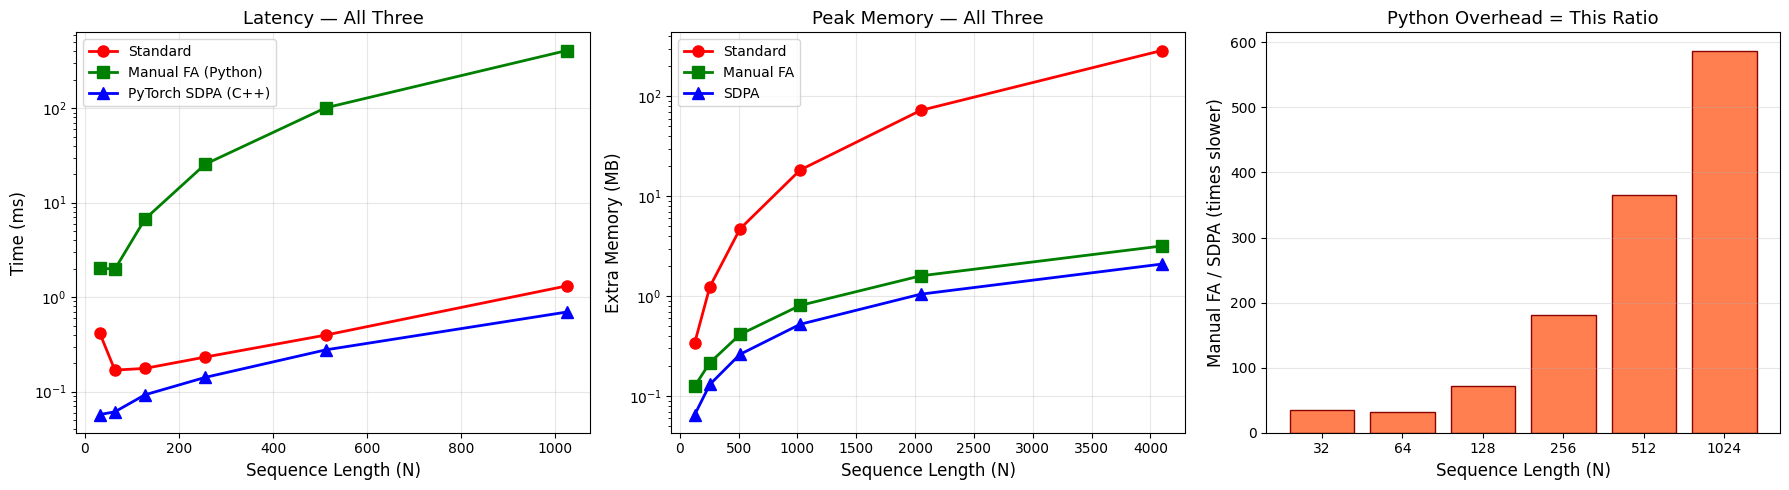


Left:   Manual FA is correct but orders of magnitude slower (Python loops)
Center: Manual FA uses LESS memory than Standard (no N×N) — algorithm works!
Right:  The bar chart shows pure Python overhead vs C++/CUDA

→ The ALGORITHM is what saves memory. Writing it in C++/CUDA is what saves time.
→ This is exactly why Triton exists: write the algorithm in Python-like syntax,
  compile to GPU code that runs as fast as hand-written CUDA.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Timing
if results:
    Ns = [r['N'] for r in results]
    axes[0].plot(Ns, [r['standard'] for r in results], 'ro-', label='Standard', linewidth=2, markersize=8)
    axes[0].plot(Ns, [r['manual_fa'] for r in results], 'gs-', label='Manual FA (Python)', linewidth=2, markersize=8)
    axes[0].plot(Ns, [r['sdpa'] for r in results], 'b^-', label='PyTorch SDPA (C++)', linewidth=2, markersize=8)
    axes[0].set_xlabel('Sequence Length (N)', fontsize=12)
    axes[0].set_ylabel('Time (ms)', fontsize=12)
    axes[0].set_title('Latency — All Three', fontsize=13)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

# Plot 2: Memory
if mem_results:
    Ns_m = [r['N'] for r in mem_results]
    axes[1].plot(Ns_m, [r['standard']/1e6 for r in mem_results], 'ro-', label='Standard', linewidth=2, markersize=8)
    axes[1].plot(Ns_m, [r['manual_fa']/1e6 for r in mem_results], 'gs-', label='Manual FA', linewidth=2, markersize=8)
    axes[1].plot(Ns_m, [r['sdpa']/1e6 for r in mem_results], 'b^-', label='SDPA', linewidth=2, markersize=8)
    axes[1].set_xlabel('Sequence Length (N)', fontsize=12)
    axes[1].set_ylabel('Extra Memory (MB)', fontsize=12)
    axes[1].set_title('Peak Memory — All Three', fontsize=13)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')

# Plot 3: Manual/SDPA ratio
if results:
    axes[2].bar([str(r['N']) for r in results], [r['ratio'] for r in results],
                color='coral', edgecolor='darkred')
    axes[2].set_xlabel('Sequence Length (N)', fontsize=12)
    axes[2].set_ylabel('Manual FA / SDPA (times slower)', fontsize=12)
    axes[2].set_title('Python Overhead = This Ratio', fontsize=13)
    axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nLeft:   Manual FA is correct but orders of magnitude slower (Python loops)')
print('Center: Manual FA uses LESS memory than Standard (no N×N) — algorithm works!')
print('Right:  The bar chart shows pure Python overhead vs C++/CUDA')
print('\n→ The ALGORITHM is what saves memory. Writing it in C++/CUDA is what saves time.')
print('→ This is exactly why Triton exists: write the algorithm in Python-like syntax,')
print('  compile to GPU code that runs as fast as hand-written CUDA.')

## 7. What You Learned

| | Standard | Manual FA | PyTorch SDPA |
|---|---|---|---|
| **Algorithm** | Materialized N×N | Online softmax, tiled | Online softmax, tiled |
| **Memory** | O(N²) per head | O(block²) per head | O(block²) per head |
| **Speed** | GPU-fast (but memory-bound) | Python-slow (loop overhead) | GPU-fast (compute-bound) |
| **Max N on L4** | ~8K-16K | ~8K-16K (slow!) | ~32K-65K |

**Key takeaway**: Manual FA and SDPA use the SAME algorithm. The speed gap = Python dispatch overhead. The memory gap between Standard and Manual FA = the algorithm working. That's your proof that FlashAttention's tiling is correct and effective.